**bold text**

Cell 1 — Install & Imports

In [ ]:
# If running in Colab, uncomment:
# !pip install kagglehub torchmetrics -q

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import seaborn as sns

# Reproducibility (matches the report: seed = 42)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


Cell 2 — Download the dataset from Kaggle

In [ ]:
import kagglehub

# Downloads (or reuses cached) dataset and returns the local path
dataset_path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")
print("Dataset downloaded to:", dataset_path)

# Inspect folder structure
for item in sorted(Path(dataset_path).rglob("*"))[:20]:
    print(item)

100%|██████████| 1.07G/1.07G [00:17<00:00, 64.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original/battery
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original/battery/battery_1.jpg
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original/battery/battery_10.jpg
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original/battery/battery_100.jpg
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original/battery/battery_101.jpg
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original/battery/battery_102.jpg
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original/battery/battery_103.jpg
/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v

Cell 3 — Locate the class folders

In [ ]:
# The dataset is organized as: garbage-dataset/<class_name>/*.jpg
DATA_ROOT = None
for p in Path(dataset_path).rglob("*"):
    if p.is_dir() and p.name.lower() in {"battery","biological","cardboard","clothes",
                                          "glass","metal","paper","plastic","shoes","trash"}:
        DATA_ROOT = p.parent
        break

print("Detected data root:", DATA_ROOT)
CLASSES = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print("Classes found:", CLASSES)

CLASS_TO_IDX = {
    "battery": 0, "biological": 1, "cardboard": 2, "clothes": 3, "glass": 4,
    "metal": 5, "paper": 6, "plastic": 7, "shoes": 8, "trash": 9
}

Detected data root: /root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original
Classes found: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


Cell 4 — Build a manifest (image path + label) and inspect class distribution

Total images: 12259
label_name
clothes       1892
glass         1736
plastic       1597
shoes         1449
cardboard     1411
paper         1336
metal          930
battery        756
biological     699
trash          453
Name: count, dtype: int64


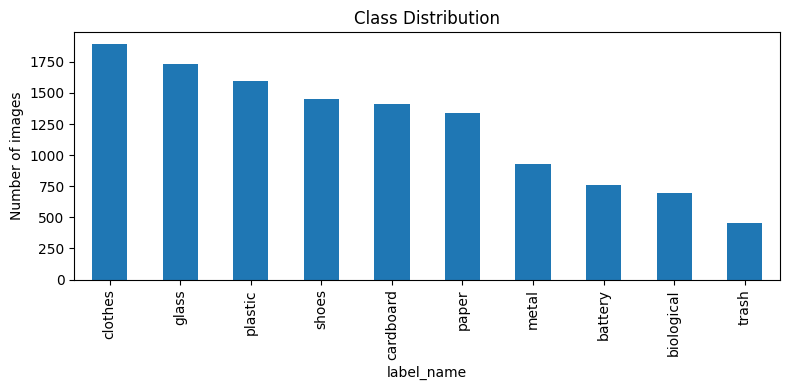

In [ ]:
records = []
for cls in CLASSES:
    cls_dir = DATA_ROOT / cls
    for img_path in cls_dir.glob("*"):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({"filepath": str(img_path), "label_name": cls,
                             "label": CLASS_TO_IDX[cls]})

df = pd.DataFrame(records)
print("Total images:", len(df))
print(df["label_name"].value_counts())

df["label_name"].value_counts().plot(kind="bar", figsize=(8,4), title="Class Distribution")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

Cell 5 — Stratified 70:15:15 split (matches report methodology, seed=42)

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

# Save manifests for reproducibility (as described in the report, Section 4.2)
os.makedirs("manifests", exist_ok=True)
train_df.to_csv("manifests/train.csv", index=False)
val_df.to_csv("manifests/val.csv", index=False)
test_df.to_csv("manifests/test.csv", index=False)

Train: 8581 Val: 1839 Test: 1839


Cell 6 — Transforms (training augmentation vs deterministic eval)

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

Cell 7 — Custom Dataset class

In [ ]:
class WasteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")  # standardize colour mode
        if self.transform:
            image = self.transform(image)
        label = int(row["label"])
        return image, label

train_dataset = WasteDataset(train_df, transform=train_transform)
val_dataset   = WasteDataset(val_df, transform=eval_transform)
test_dataset  = WasteDataset(test_df, transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Batches -> train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))

Batches -> train: 269 val: 58 test: 58


Cell 8 — Custom CNN architecture

This is a task-specific CNN built from scratch (no pretrained weights) — five convolutional blocks with batch normalization, ReLU, and max-pooling, followed by a fully connected classifier head with dropout for regularization.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        self.block1 = conv_block(3, 32)     # 224 -> 112
        self.block2 = conv_block(32, 64)    # 112 -> 56
        self.block3 = conv_block(64, 128)   # 56 -> 28
        self.block4 = conv_block(128, 256)  # 28 -> 14
        self.block5 = conv_block(256, 512)  # 14 -> 7

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

model = CustomCNN(num_classes=10).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,850,090
Trainable parameters: 4,850,090


Cell 9 — Loss, optimizer, scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

Cell 10 — Training loop (with validation each epoch)

In [ ]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

Epoch 01/25 | Train Loss: 1.9419 Acc: 0.3219 | Val Loss: 1.8286 Acc: 0.3480
  -> Saved new best checkpoint


Cell 11 — Plot training curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

Cell 12 — Load best checkpoint and evaluate on the held-out test set

In [ ]:
model.load_state_dict(torch.load("best_custom_cnn.pth"))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

zCell 13 — Metrics: accuracy, precision, recall, F1 (macro & weighted)

In [ ]:
acc = accuracy_score(all_labels, all_preds)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0)
precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0)

print(f"Test Accuracy: {acc:.4f}")
print(f"Macro    Precision: {precision_macro:.4f} | Recall: {recall_macro:.4f} | F1: {f1_macro:.4f}")
print(f"Weighted Precision: {precision_w:.4f} | Recall: {recall_w:.4f} | F1: {f1_w:.4f}")

print("\nPer-class report:")
print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))

Cell 14 — ROC-AUC (one-vs-rest, multiclass)

In [ ]:
y_true_bin = label_binarize(all_labels, classes=list(range(10)))
roc_auc = roc_auc_score(y_true_bin, all_probs, average="macro", multi_class="ovr")
print(f"Macro ROC-AUC: {roc_auc:.4f}")

Cell 15 — Confusion matrix

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Custom CNN — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

Cell 16 — Inference speed / model size (for the efficiency comparison section)

In [ ]:
import time

model.eval()
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

# Warm-up
for _ in range(10):
    _ = model(dummy)

start = time.time()
n_runs = 100
with torch.no_grad():
    for _ in range(n_runs):
        _ = model(dummy)
elapsed = time.time() - start

print(f"Avg inference latency: {(elapsed / n_runs) * 1000:.2f} ms")
print(f"Throughput: {n_runs / elapsed:.2f} images/sec")

model_size_mb = os.path.getsize("best_custom_cnn.pth") / (1024 * 1024)
print(f"Checkpoint size: {model_size_mb:.2f} MB")